In [1]:
import subprocess
subprocess.run(["pip", "install", "-q", "scikit-learn"], check=True)
import sklearn
print("scikit-learn version:", sklearn.__version__)

scikit-learn version: 1.6.1


In [2]:
import os
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ── Paths ──────────────────────────────────────────────────────────────────────
PREPROCESSING_DIR = Path("/kaggle/input/notebooks/adityarajpaul/02-preprocessing/exports")
FINE_TUNING_DIR   = Path("/kaggle/input/notebooks/adityarajpaul/04-fine-tuning/fine_tuning")
OUTPUT_DIR        = Path("/kaggle/working/evaluation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = FINE_TUNING_DIR / "finetuned_best.keras"

# ── Constants ─────────────────────────────────────────────────────────────────
IMAGE_SIZE  = (300, 300)
BATCH_SIZE  = 32
NUM_CLASSES = 38

print("TensorFlow version:", tf.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))
print("Model path exists:", MODEL_PATH.exists())

2026-06-09 09:49:57.827066: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780998598.045673      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780998598.109824      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780998598.609190      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780998598.609228      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780998598.609231      22 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Model path exists: True


In [3]:
with open(PREPROCESSING_DIR / "class_mapping.json") as f:
    class_mapping = json.load(f)   # {"0": "Apple___Apple_scab", ...}

with open(PREPROCESSING_DIR / "class_weights.json") as f:
    class_weights_raw = json.load(f)

with open(PREPROCESSING_DIR / "dataset_splits.json") as f:
    dataset_splits = json.load(f)

class_weights = {int(k): v for k, v in class_weights_raw.items()}

# Integer index → clean display name
idx_to_class = {int(k): v for k, v in class_mapping.items()}

# Clean display names: "Apple___Apple_scab" → "Apple: Apple Scab"
def clean_label(raw):
    parts = raw.split("___")
    plant   = parts[0].replace("_", " ")
    disease = parts[1].replace("_", " ").replace("(", "").replace(")", "") if len(parts) > 1 else ""
    return f"{plant}: {disease}".strip(": ")

idx_to_display = {k: clean_label(v) for k, v in idx_to_class.items()}

print(f"Classes: {len(idx_to_class)}")
print(f"Test samples: {len(dataset_splits['paths_test'])}")
print("\nSample display names:")
for i in range(3):
    print(f"  {i}: {idx_to_display[i]}")

Classes: 38
Test samples: 5431

Sample display names:
  0: Apple: Apple scab
  1: Apple: Black rot
  2: Apple: Cedar apple rust


In [4]:
AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess(file_path, label):
    image = tf.io.read_file(file_path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMAGE_SIZE)
    image = tf.cast(image, tf.float32)  # [0, 255] — EfficientNetB3 normalizes internally
    return image, label

paths  = dataset_splits["paths_test"]
labels = dataset_splits["labels_test"]

test_ds = (
    tf.data.Dataset.from_tensor_slices((paths, labels))
    .map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"Test batches: {len(test_ds)}")
print(f"Test samples: {len(paths)}")

Test batches: 170
Test samples: 5431


I0000 00:00:1780998612.822326      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780998612.828824      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [5]:
@tf.keras.utils.register_keras_serializable()
def top3_accuracy(y_true, y_pred):
    return tf.keras.metrics.sparse_top_k_categorical_accuracy(y_true, y_pred, k=3)

print("Loading model...")
model = keras.models.load_model(
    str(MODEL_PATH),
    custom_objects={"top3_accuracy": top3_accuracy}
)
print("Model loaded.")

print("\nRunning inference on test set...")
y_pred_probs = model.predict(test_ds, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = np.array(labels)

print(f"\nInference complete.")
print(f"y_true shape: {y_true.shape}")
print(f"y_pred shape: {y_pred.shape}")
print(f"Overall accuracy: {np.mean(y_true == y_pred):.4f}")

top3_correct = sum(
    y_true[i] in np.argsort(y_pred_probs[i])[-3:]
    for i in range(len(y_true))
)
print(f"Top-3 accuracy:   {top3_correct / len(y_true):.4f}")

Loading model...


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 112 variables whereas the saved optimizer has 222 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model loaded.

Running inference on test set...


I0000 00:00:1780998621.474750      72 service.cc:152] XLA service 0x7dde3c002540 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780998621.474788      72 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780998621.474792      72 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780998622.890061      72 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-09 09:50:32.694237: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 09:50:32.850851: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 09:50:33.313911: E external/local_xl

169/170 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step

2026-06-09 09:51:10.712327: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 09:51:10.861895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 09:51:11.250593: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 09:51:11.398372: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-09 09:51:12.236946: E external/local_xla/xla/stream_

170/170 ━━━━━━━━━━━━━━━━━━━━ 61s 222ms/step

Inference complete.
y_true shape: (5431,)
y_pred shape: (5431,)
Overall accuracy: 0.9908
Top-3 accuracy:   0.9998


In [6]:
display_names = [idx_to_display[i] for i in range(NUM_CLASSES)]

report_dict = classification_report(
    y_true, y_pred,
    target_names=display_names,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()

# Save full report to CSV
report_df.to_csv(OUTPUT_DIR / "classification_report.csv")

# Print formatted table for the notebook
report_str = classification_report(y_true, y_pred, target_names=display_names)
print(report_str)

                                                   precision    recall  f1-score   support

                                Apple: Apple scab       1.00      1.00      1.00        63
                                 Apple: Black rot       1.00      1.00      1.00        62
                          Apple: Cedar apple rust       1.00      1.00      1.00        27
                                   Apple: healthy       0.99      1.00      1.00       165
                               Blueberry: healthy       1.00      1.00      1.00       150
          Cherry (including sour): Powdery mildew       1.00      0.99      1.00       105
                 Cherry (including sour): healthy       1.00      1.00      1.00        85
Corn (maize): Cercospora leaf spot Gray leaf spot       0.92      0.94      0.93        51
                        Corn (maize): Common rust       1.00      1.00      1.00       119
               Corn (maize): Northern Leaf Blight       0.97      0.96      0.96        9

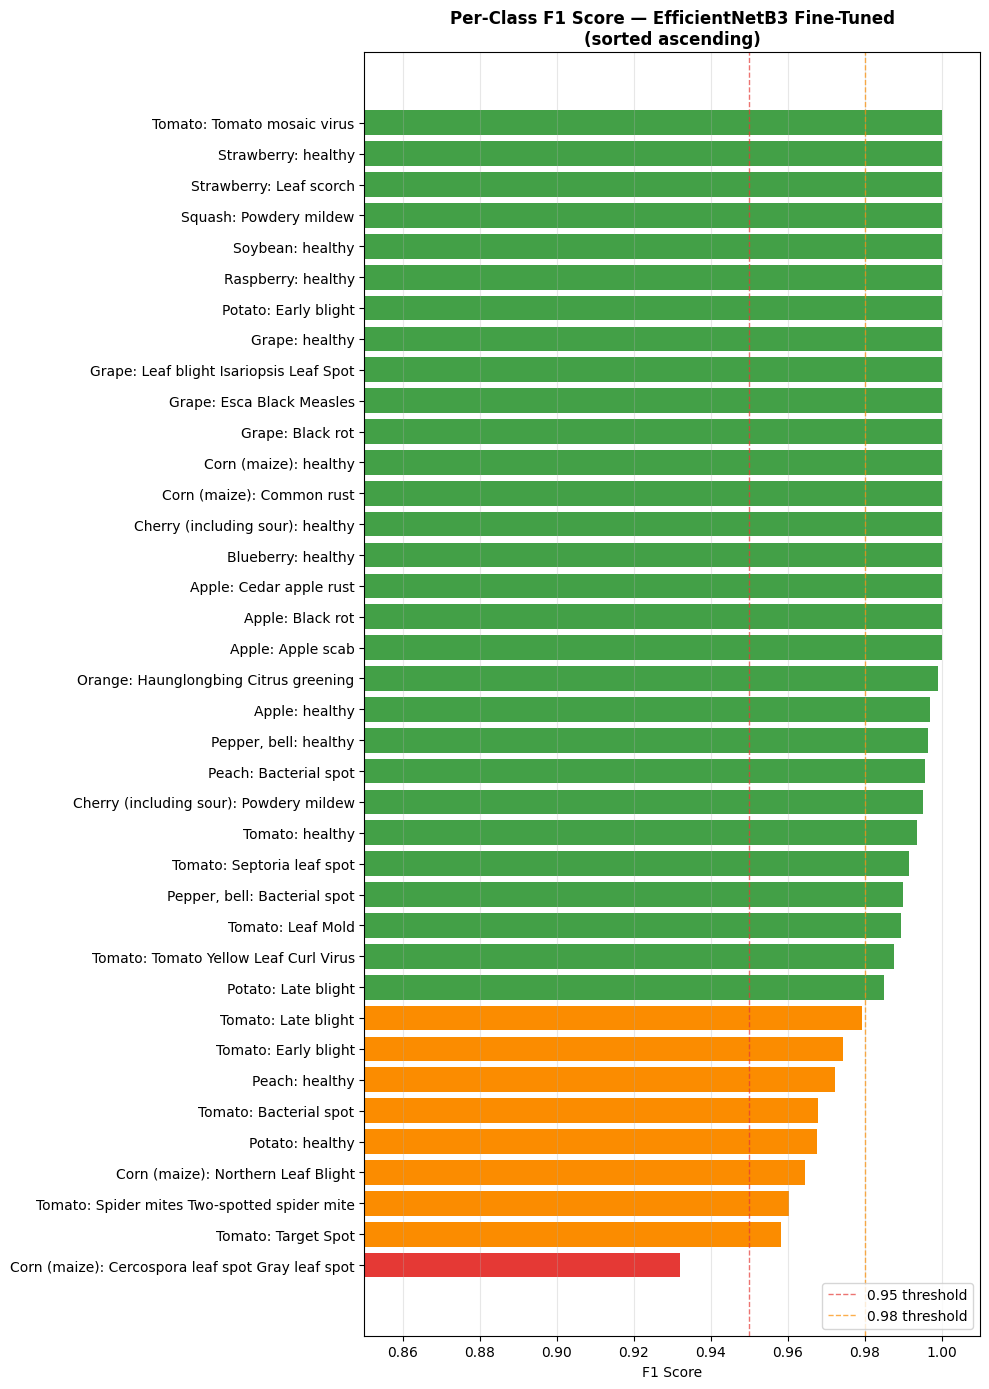

Per-class F1 chart saved.


In [7]:
# Extract per-class F1 scores (exclude aggregate rows)
class_f1 = {
    name: report_dict[name]["f1-score"]
    for name in display_names
}

sorted_items = sorted(class_f1.items(), key=lambda x: x[1])
names_sorted  = [item[0] for item in sorted_items]
f1_sorted     = [item[1] for item in sorted_items]

colors = ["#e53935" if f < 0.95 else "#FB8C00" if f < 0.98 else "#43A047"
          for f in f1_sorted]

fig, ax = plt.subplots(figsize=(10, 14))
bars = ax.barh(names_sorted, f1_sorted, color=colors)
ax.axvline(x=0.95, color="#e53935", linestyle="--", linewidth=1, alpha=0.7, label="0.95 threshold")
ax.axvline(x=0.98, color="#FB8C00", linestyle="--", linewidth=1, alpha=0.7, label="0.98 threshold")
ax.set_xlim(0.85, 1.01)
ax.set_xlabel("F1 Score")
ax.set_title("Per-Class F1 Score — EfficientNetB3 Fine-Tuned\n(sorted ascending)", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()
print("Per-class F1 chart saved.")

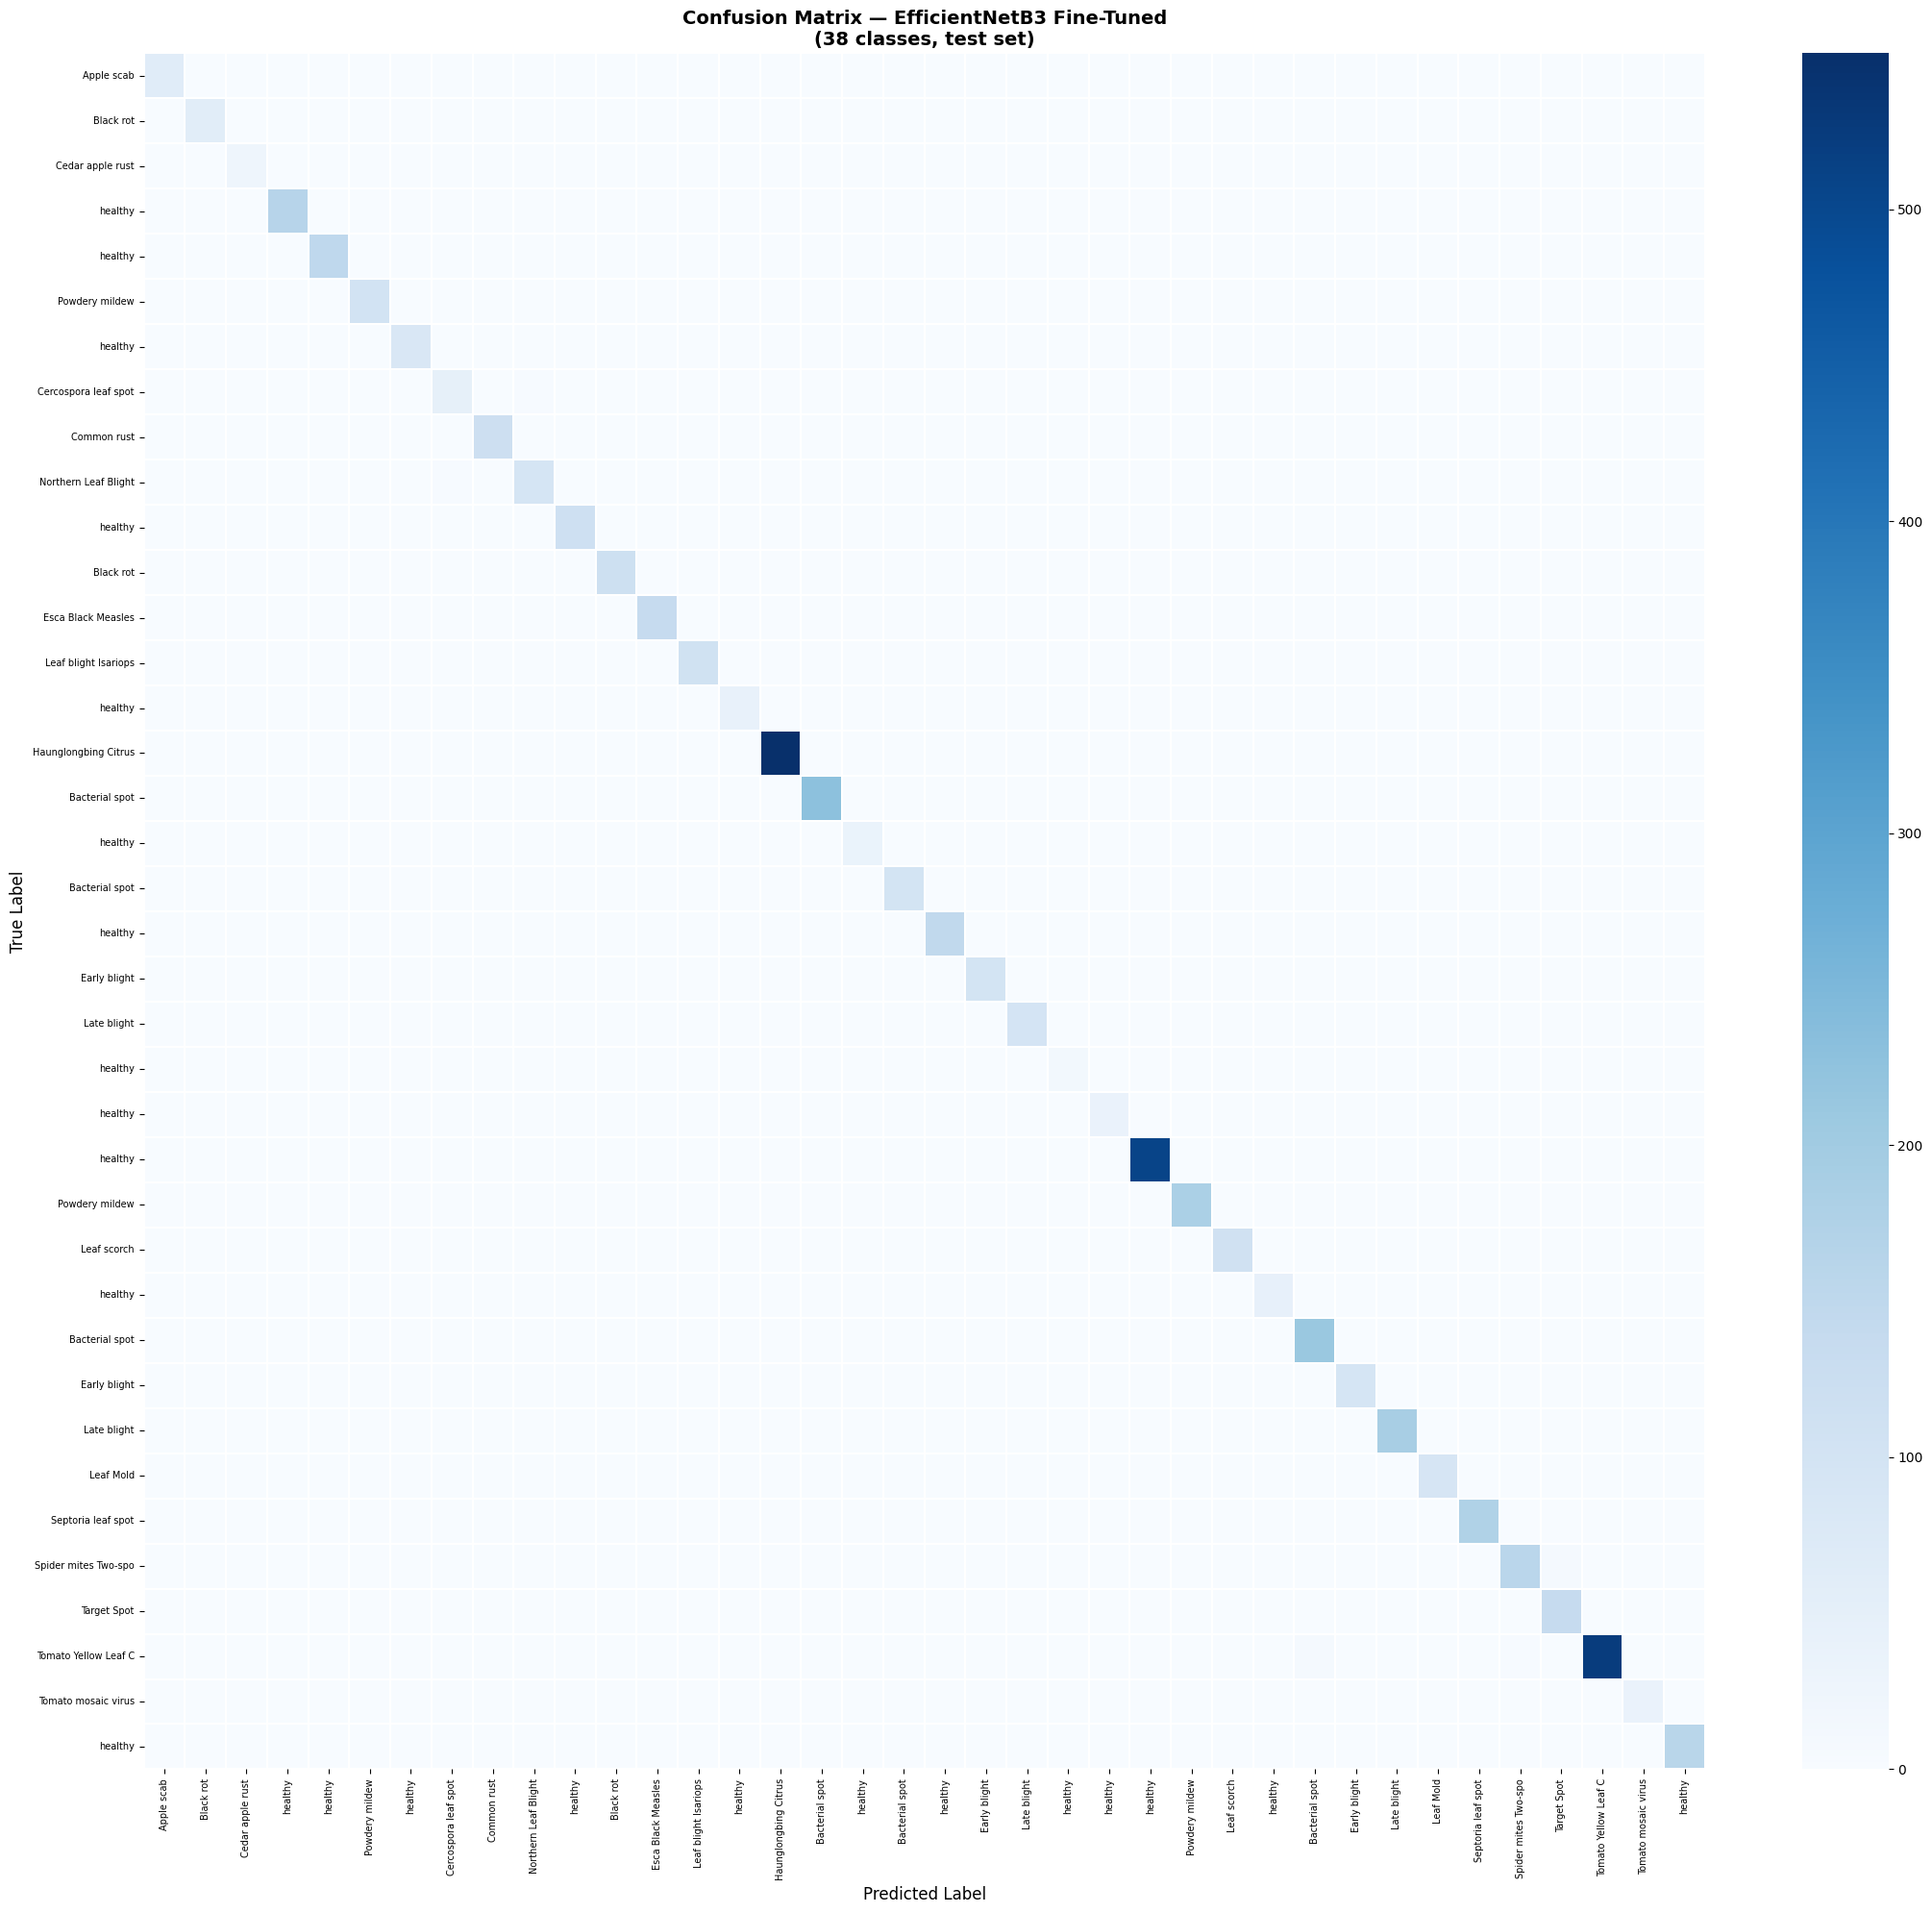

Full confusion matrix saved.


In [8]:
cm = confusion_matrix(y_true, y_pred)

# Short labels for axes (just the disease part to save space)
short_labels = [idx_to_display[i].split(": ")[-1][:20] for i in range(NUM_CLASSES)]

fig, ax = plt.subplots(figsize=(22, 20))
sns.heatmap(
    cm,
    annot=False,        # 38x38 = 1444 cells — numbers would be unreadable
    fmt="d",
    cmap="Blues",
    xticklabels=short_labels,
    yticklabels=short_labels,
    linewidths=0.3,
    ax=ax
)
ax.set_xlabel("Predicted Label", fontsize=12)
ax.set_ylabel("True Label", fontsize=12)
ax.set_title("Confusion Matrix — EfficientNetB3 Fine-Tuned\n(38 classes, test set)", fontweight="bold", fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_full.png", dpi=150, bbox_inches="tight")
plt.show()
print("Full confusion matrix saved.")

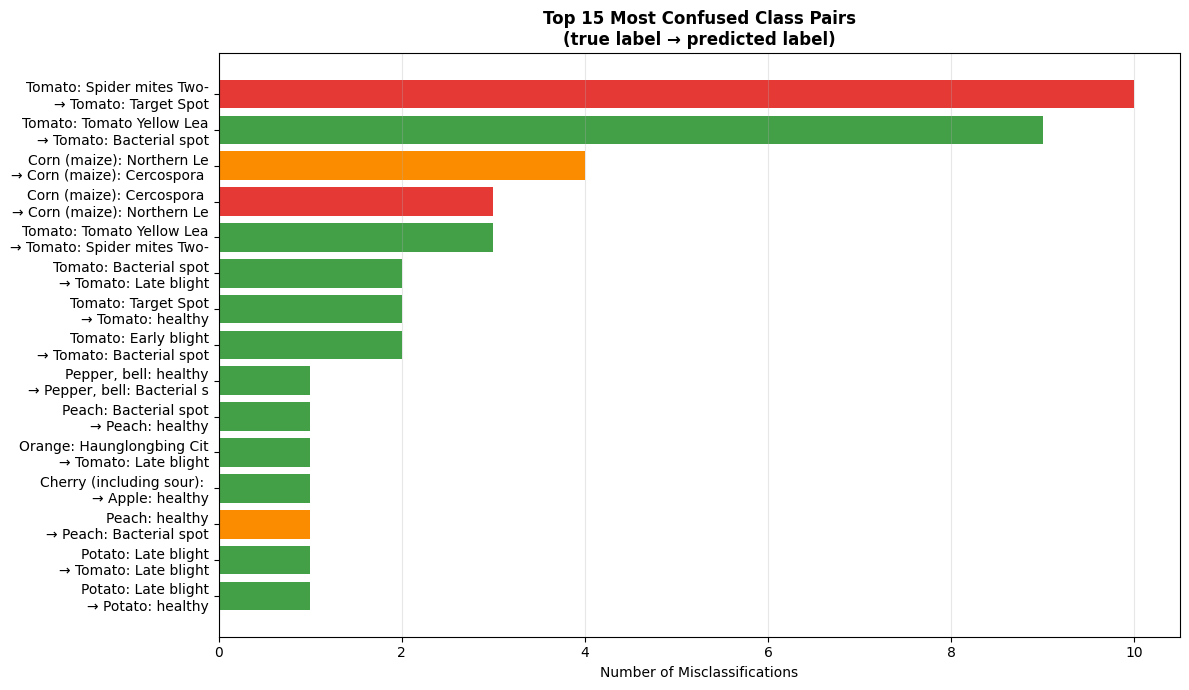

Top confused pairs chart saved.

Top 10 confused pairs:
                                             true                                         predicted  count  error_rate
     Tomato: Spider mites Two-spotted spider mite                               Tomato: Target Spot     10    0.059524
            Tomato: Tomato Yellow Leaf Curl Virus                            Tomato: Bacterial spot      9    0.016791
               Corn (maize): Northern Leaf Blight Corn (maize): Cercospora leaf spot Gray leaf spot      4    0.040404
Corn (maize): Cercospora leaf spot Gray leaf spot                Corn (maize): Northern Leaf Blight      3    0.058824
            Tomato: Tomato Yellow Leaf Curl Virus      Tomato: Spider mites Two-spotted spider mite      3    0.005597
                           Tomato: Bacterial spot                               Tomato: Late blight      2    0.009390
                              Tomato: Target Spot                                   Tomato: healthy      2    0

In [9]:
# Zero out the diagonal (correct predictions) to isolate confusions
cm_no_diag = cm.copy().astype(float)
np.fill_diagonal(cm_no_diag, 0)

# Extract top 15 confused pairs
confused_pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if cm_no_diag[i, j] > 0:
            confused_pairs.append({
                "true":       idx_to_display[i],
                "predicted":  idx_to_display[j],
                "count":      int(cm_no_diag[i, j]),
                "true_total": int(cm[i].sum()),
                "error_rate": cm_no_diag[i, j] / cm[i].sum()
            })

confused_df = pd.DataFrame(confused_pairs).sort_values("count", ascending=False).head(15)
confused_df.to_csv(OUTPUT_DIR / "top_confused_pairs.csv", index=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
pair_labels = [f"{row['true'][:25]}\n→ {row['predicted'][:25]}"
               for _, row in confused_df.iterrows()]
colors_conf = ["#e53935" if r > 0.05 else "#FB8C00" if r > 0.02 else "#43A047"
               for r in confused_df["error_rate"]]

ax.barh(pair_labels[::-1], confused_df["count"].values[::-1], color=colors_conf[::-1])
ax.set_xlabel("Number of Misclassifications")
ax.set_title("Top 15 Most Confused Class Pairs\n(true label → predicted label)", fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top_confused_pairs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Top confused pairs chart saved.")
print("\nTop 10 confused pairs:")
print(confused_df[["true", "predicted", "count", "error_rate"]].head(10).to_string(index=False))

Total misclassified: 50 / 5431 (0.92%)


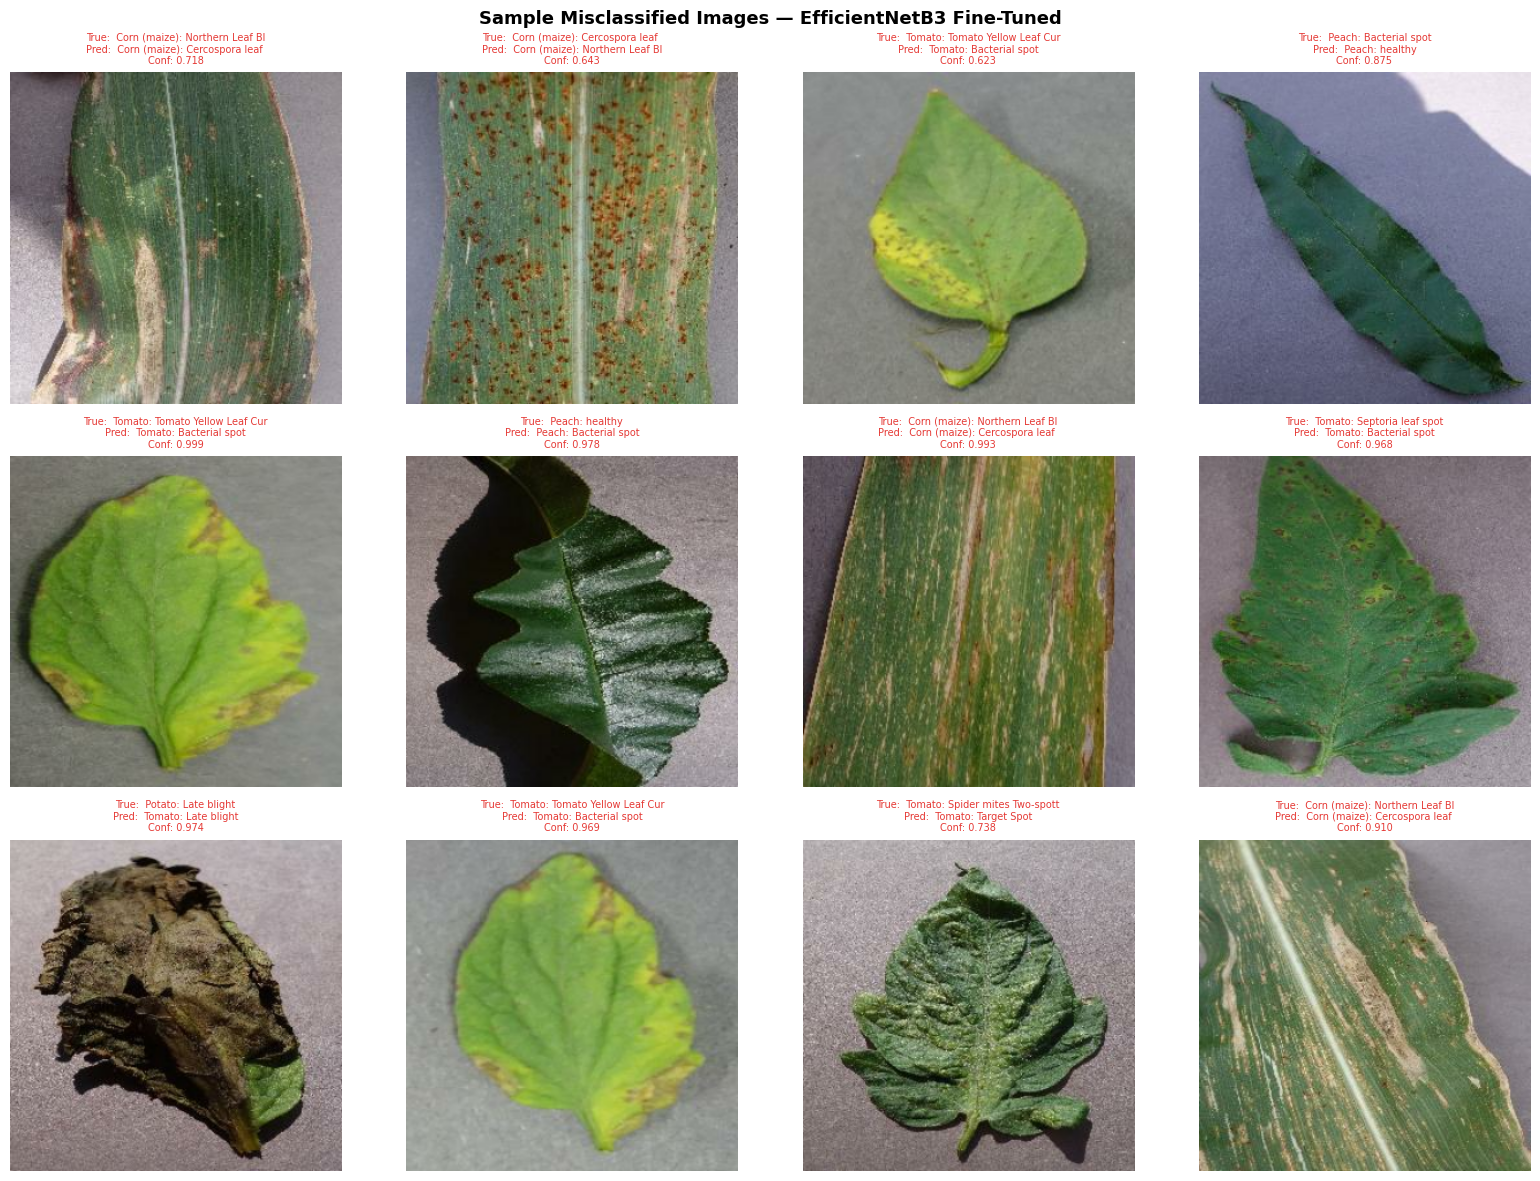

Misclassified samples saved.


In [10]:
# Find misclassified indices
misclassified_idx = np.where(y_true != y_pred)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_true)} "
      f"({len(misclassified_idx)/len(y_true)*100:.2f}%)")

# Sample 12 misclassified images
np.random.seed(42)
sample_idx = np.random.choice(misclassified_idx, size=min(12, len(misclassified_idx)), replace=False)

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for plot_i, data_i in enumerate(sample_idx):
    # Load the image directly from path
    img_path = paths[data_i]
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = tf.cast(img, tf.uint8).numpy()

    true_label = idx_to_display[y_true[data_i]]
    pred_label = idx_to_display[y_pred[data_i]]
    confidence = y_pred_probs[data_i][y_pred[data_i]]

    axes[plot_i].imshow(img)
    axes[plot_i].set_title(
        f"True:  {true_label[:30]}\nPred:  {pred_label[:30]}\nConf: {confidence:.3f}",
        fontsize=7, color="#e53935"
    )
    axes[plot_i].axis("off")

plt.suptitle("Sample Misclassified Images — EfficientNetB3 Fine-Tuned",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "misclassified_samples.png", dpi=150, bbox_inches="tight")
plt.show()
print("Misclassified samples saved.")

In [11]:
overall_acc  = np.mean(y_true == y_pred)
top3_acc     = top3_correct / len(y_true)
total_errors = len(misclassified_idx)

# Best and worst classes by F1
best_class  = max(class_f1, key=class_f1.get)
worst_class = min(class_f1, key=class_f1.get)

print("=" * 60)
print("EVALUATION SUMMARY — EfficientNetB3 Fine-Tuned")
print("=" * 60)
print(f"Test samples:          {len(y_true)}")
print(f"Overall accuracy:      {overall_acc:.4f}")
print(f"Top-3 accuracy:        {top3_acc:.4f}")
print(f"Total misclassified:   {total_errors} ({total_errors/len(y_true)*100:.2f}%)")
print()
print(f"Best class  (F1): {best_class}")
print(f"            F1  = {class_f1[best_class]:.4f}")
print()
print(f"Worst class (F1): {worst_class}")
print(f"            F1  = {class_f1[worst_class]:.4f}")
print()
print("Files saved to /kaggle/working/evaluation/:")
for f in sorted(OUTPUT_DIR.iterdir()):
    size_mb = f.stat().st_size / (1024 * 1024)
    print(f"  {f.name:<45} {size_mb:.2f} MB")
print()
print("NEXT STEP: Commit this notebook, then proceed to 06_export.ipynb")

EVALUATION SUMMARY — EfficientNetB3 Fine-Tuned
Test samples:          5431
Overall accuracy:      0.9908
Top-3 accuracy:        0.9998
Total misclassified:   50 (0.92%)

Best class  (F1): Apple: Apple scab
            F1  = 1.0000

Worst class (F1): Corn (maize): Cercospora leaf spot Gray leaf spot
            F1  = 0.9320

Files saved to /kaggle/working/evaluation/:
  classification_report.csv                     0.00 MB
  confusion_matrix_full.png                     0.20 MB
  misclassified_samples.png                     3.62 MB
  per_class_f1.png                              0.24 MB
  top_confused_pairs.csv                        0.00 MB
  top_confused_pairs.png                        0.15 MB

NEXT STEP: Commit this notebook, then proceed to 06_export.ipynb
